# Customer Churn Prediction & Retention Analytics

## Project Objective
This project aims to analyze customer churn and build a machine learning model that predicts whether a customer is likely to leave the company.

Customer churn is an important business problem because retaining existing customers is often more cost-effective than acquiring new ones. The goal of this project is to identify the main drivers of churn and generate insights that can support customer retention strategies.

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

In [1]:
# Import core data analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Load the customer churn dataset
df = pd.read_csv("customer_churn.csv")

# Display the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Overview

The dataset contains customer-level information such as:
- demographic variables
- account and contract details
- services used
- billing information
- churn status

The target variable is `Churn`, which indicates whether the customer left the company.

In [3]:
# Check number of rows and columns
df.shape

(7043, 21)

In [4]:
# View column names
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [5]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
# Summary statistics for numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Cleaning

Before building a predictive model, we need to:
- check for missing values
- correct data types
- prepare the churn column for modelling

In [7]:
# Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Now for `TotalCharges`, this dataset often stores some values as text or blanks.

In [8]:
# Convert TotalCharges to numeric
# Invalid values are turned into NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
# Check missing values again
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
# Fill missing TotalCharges values with the median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [11]:
# Confirm the column type
df["TotalCharges"].dtype

dtype('float64')

## Exploratory Data Analysis

We begin by understanding how churn is distributed across customers.

In [12]:
# Count churn values
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

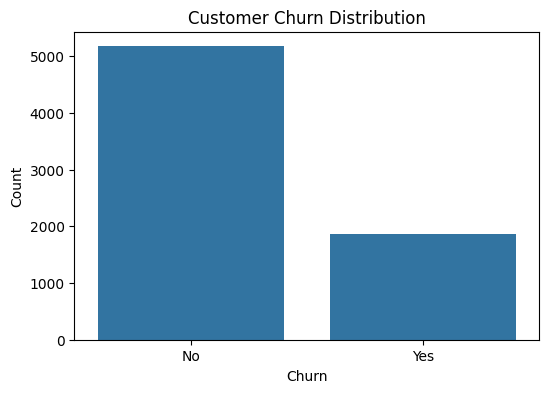

In [13]:
# Plot churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

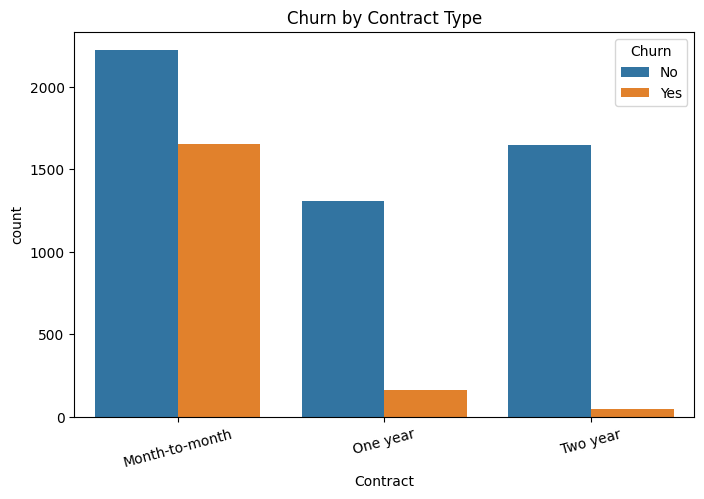

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

Customers on month-to-month contracts are generally more likely to churn than customers on longer-term contracts.

<function matplotlib.pyplot.show(close=None, block=None)>

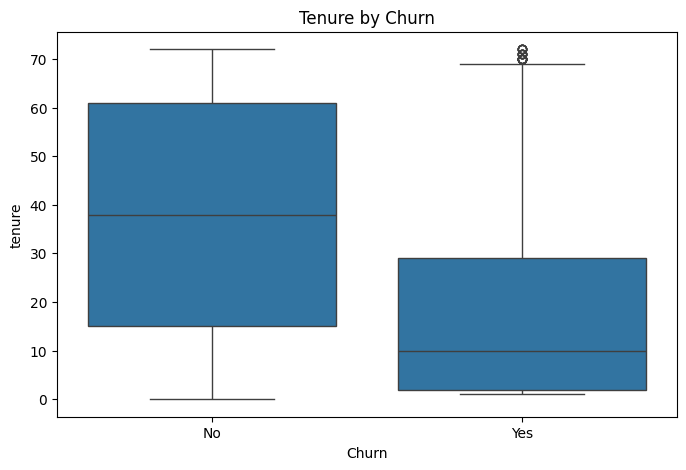

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure by Churn")
plt.show

Customers who churn tend to have shorter tenure, suggesting that newer customers are at higher risk of leaving.

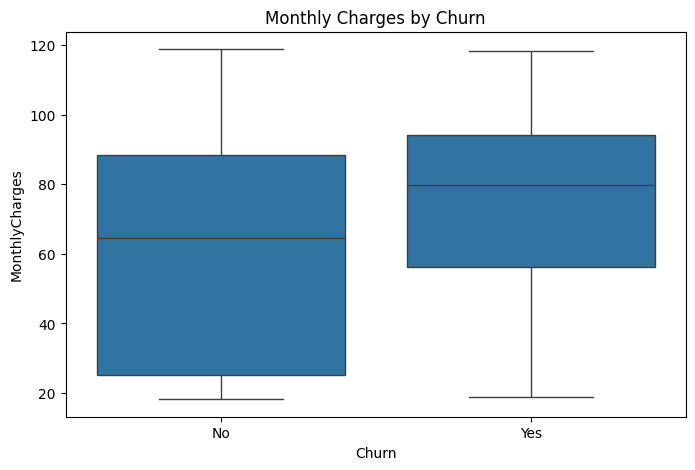

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.show()

Customers with higher monthly charges may be more likely to churn, indicating pricing sensitivity.

## Preprocessing

Machine learning models require numeric input, so categorical variables need to be encoded.

In [17]:
# Convert target variable into numeric form
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [18]:
# Drop customerID because it is just an identifier
df = df.drop("customerID", axis=1)

In [19]:
# Encode categorical columns
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

In [20]:
# Confirm data types after encoding
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [21]:
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [22]:
# Convert categorical variables to numeric using get_dummies
df = pd.get_dummies(df, drop_first=True)

In [23]:
# Define features and target variable
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [24]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Encoding Categorical Variables

The dataset contains several categorical variables such as gender, contract type, and payment method. These variables were converted into numeric form using one-hot encoding to allow them to be used in machine learning models.

## Model Building

A Random Forest Classifier is used to predict customer churn.
This model is suitable because it handles structured tabular data well and can provide feature importance scores.

In [25]:
# Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [26]:
# Generate predictions
y_pred = model.predict(X_test)

In [27]:
# Model accuracy
accuracy_score(y_test, y_pred)

0.7892122072391767

In [28]:
# Confusion matrix
confusion_matrix(y_test, y_pred)

array([[941,  95],
       [202, 171]])

In [29]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



## Model Performance Interpretation

The Random Forest model achieved an overall accuracy of 79%, indicating good general predictive performance.

However, for churn prediction, recall for churned customers is especially important. The model achieved:

- Churn precision: 0.64  
- Churn recall: 0.46  

This means:
- 64% of predicted churners were correct
- The model identified 46% of actual churners

This suggests the model is conservative in predicting churn and may miss some at-risk customers.

In real business settings, improving recall is often preferred so more at-risk customers can be targeted for retention campaigns.

The evaluation metrics show how well the model distinguishes between churned and non-churned customers. In churn prediction, it is especially important to pay attention to recall for churned customers, since missing at-risk customers can reduce the effectiveness of retention strategies.

In [30]:
# Extract feature importance values
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

TotalCharges                      0.189701
tenure                            0.175710
MonthlyCharges                    0.172418
InternetService_Fiber optic       0.036053
PaymentMethod_Electronic check    0.035302
Contract_Two year                 0.030435
OnlineSecurity_Yes                0.029238
gender_Male                       0.027423
PaperlessBilling_Yes              0.025295
Partner_Yes                       0.024209
dtype: float64

## Feature Importance Analysis

The Random Forest model identifies the most important features influencing customer churn.

The top predictors of churn include:

- TotalCharges  
- Tenure  
- MonthlyCharges  
- InternetService (Fiber optic)  
- PaymentMethod (Electronic check)  
- Contract type (Two year)  
- OnlineSecurity  
- PaperlessBilling  

These features have the highest impact on churn prediction.

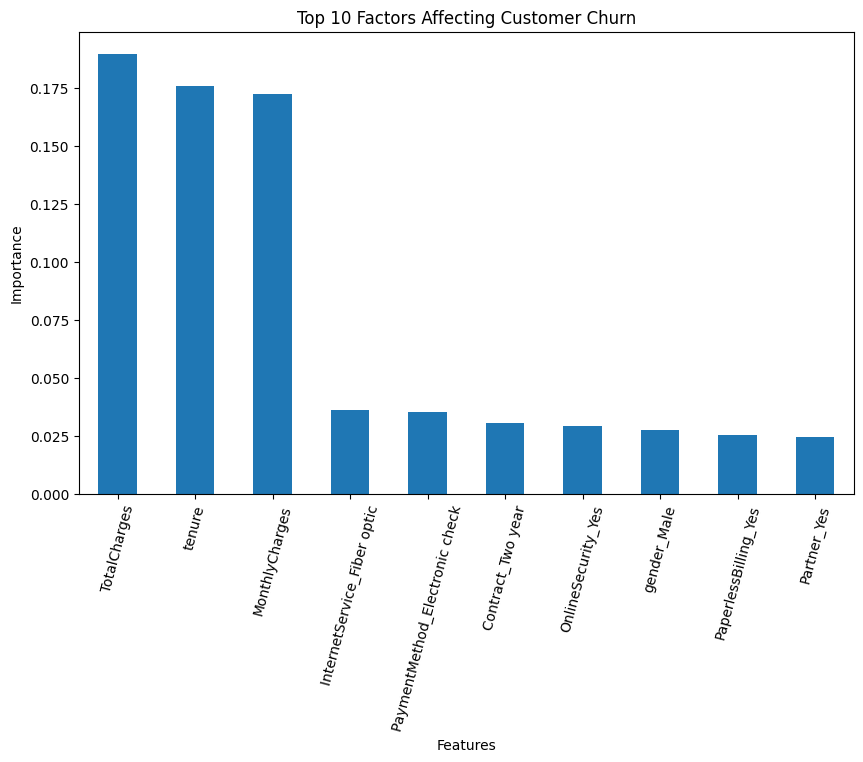

In [31]:
# Plot top 10 important features
plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind="bar")
plt.title("Top 10 Factors Affecting Customer Churn")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=75)
plt.show()

## Business Insights

The model suggests that customer churn is primarily influenced by pricing, contract structure, and service-related factors.

Key observations:

• Customers with higher **TotalCharges** are more likely to churn  
• Customers with shorter **tenure** have higher churn risk  
• Higher **MonthlyCharges** increases probability of churn  
• Customers using **fiber optic internet** show higher churn rates  
• Customers paying via **electronic check** are more likely to churn  
• Customers on **long-term contracts** are less likely to churn  
• Customers without **online security** show higher churn probability  

These findings suggest that churn risk is driven by pricing sensitivity, contract flexibility, and perceived service value.

## Conclusion

This project developed a machine learning model to predict customer churn and identify key churn drivers.

The model achieved 79% accuracy and identified pricing, tenure, and contract structure as the most important factors affecting churn.

The analysis demonstrates how predictive analytics can be used to:

- identify customers at risk of leaving  
- understand key churn drivers  
- support targeted retention strategies  
- improve customer lifetime value  

This project showcases skills in data cleaning, exploratory analysis, feature engineering, machine learning, and business interpretation.